In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning function

In [4]:
df=pd.read_csv("heart.csv")

In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.shape

(918, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [8]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [9]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [11]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

In [29]:
df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

# EDA (GRAPH Work Start Here)

# 1. Target Distribution
Q: Is my dataset balanced or not?

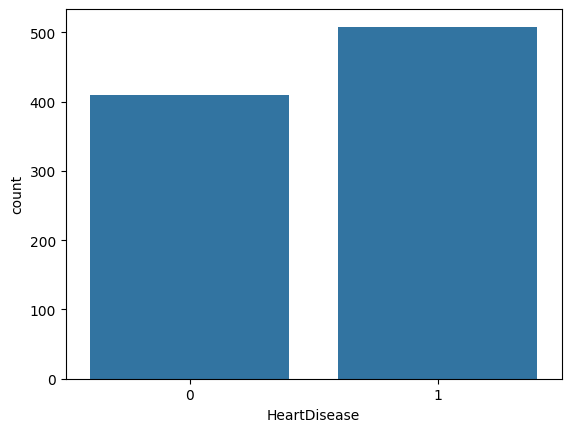

In [22]:
sns.countplot(x='HeartDisease', data=df)
plt.show()

# 2. Age Distribution

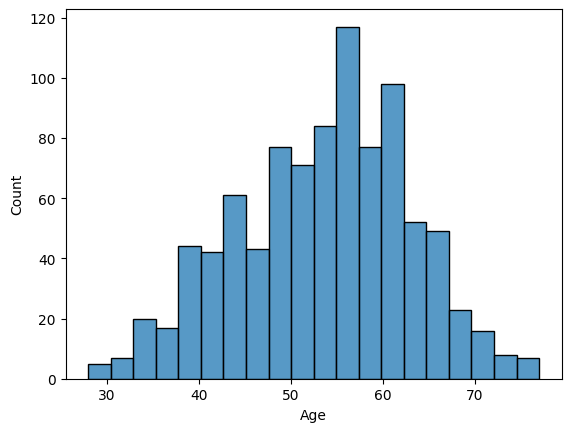

In [23]:
sns.histplot(df['Age'], bins=20)
plt.show()

# 3. Age vs Heart Disease

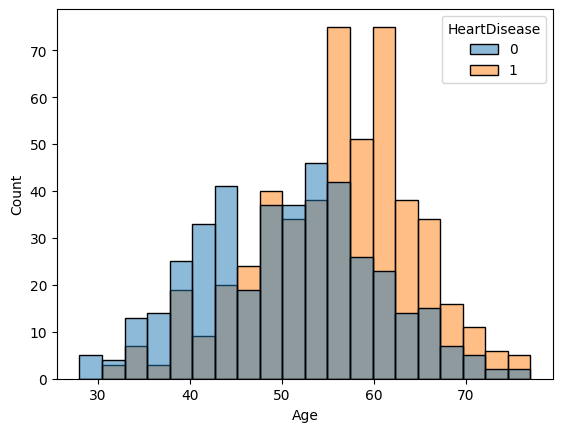

In [24]:
sns.histplot(data=df, x='Age', hue='HeartDisease', bins=20)
plt.show()

# 4. Correlation Heatmap
Which features are important?

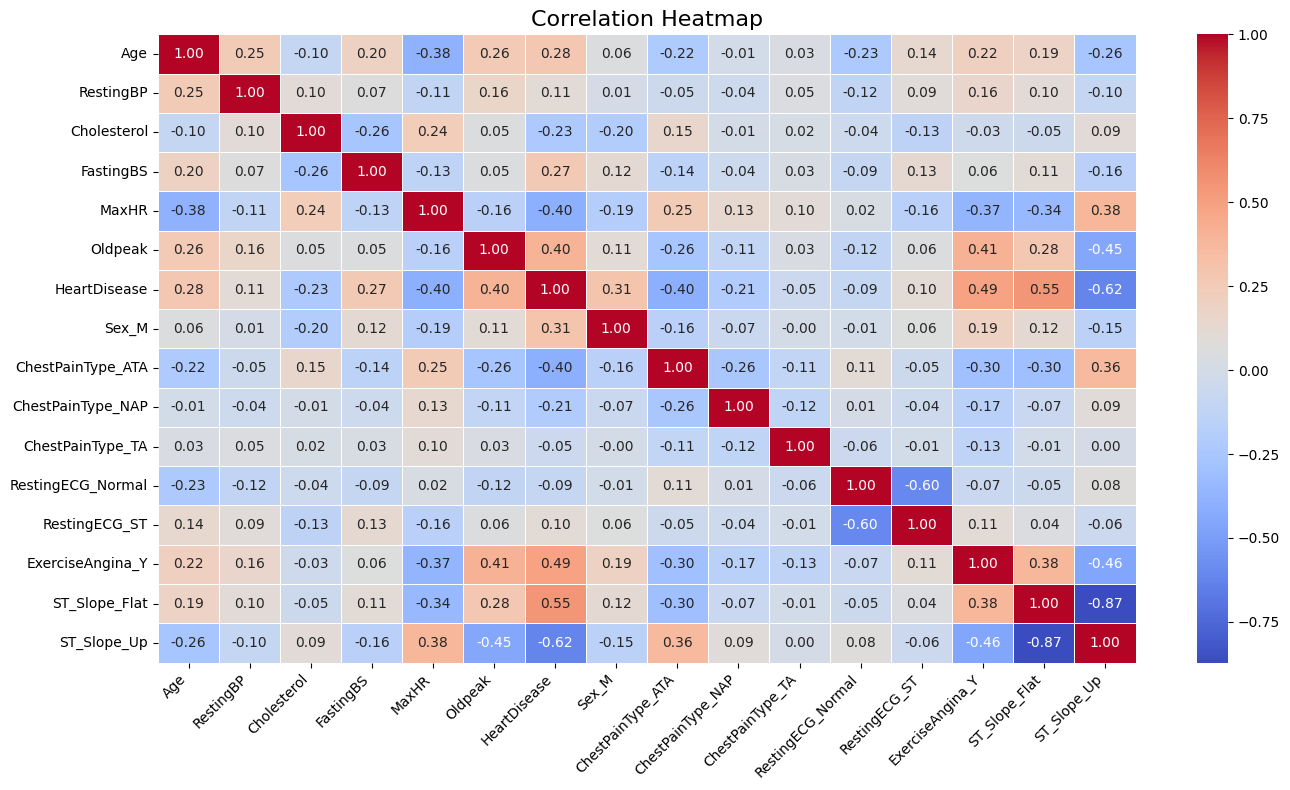

In [ ]:

plt.figure(figsize=(14, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",       
    cmap="coolwarm",
    linewidths=0.5       
)

plt.title("Correlation Heatmap", fontsize=16)

plt.xticks(rotation=45, ha='right')  
plt.yticks(rotation=0)              

plt.tight_layout() 
plt.show()

## How to Read Heatmap Colors (Quick Guide)

Use this rule of thumb for correlation values (from -1 to +1):

- **Dark red (close to +1)**: strong positive relation.
  If one feature increases, the other usually increases too.
- **Dark blue (close to -1)**: strong negative relation.
  If one feature increases, the other usually decreases.
- **Light/near white (close to 0)**: weak or no linear relation.


### Questions you can answer from colors

- **Which features are strongly linked with `HeartDisease`?**
  Look at the `HeartDisease` row/column and find dark red or dark blue cells.
- **Which features may be redundant with each other?**
  Look for non-target feature pairs with very high absolute correlation (for example, `|corr| >= 0.8`).
- **Which features add different information?**
  Prefer features with lower inter-correlation but meaningful correlation with `HeartDisease`.

### Practical thresholds

- `|corr| >= 0.70`: strong
- `0.40 <= |corr| < 0.70`: moderate
- `|corr| < 0.40`: weak

For logistic regression, this helps you spot multicollinearity risk and choose cleaner feature sets.

# Library Imports

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [13]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Split Features & Target

In [14]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Handled Categorial Data

In [16]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Train Model

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Make Prediction

In [18]:
y_pred = model.predict(X_test)

# Evaluation Model

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.8532608695652174
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



# Create prediction function

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

age = widgets.IntText(value=50, description='Age')
sex = widgets.Dropdown(options=['Male', 'Female'], value='Male', description='Sex')
chest_pain_type = widgets.Dropdown(options=[('ATA - Atypical Angina', 'ATA'), ('NAP - Non-Anginal Pain', 'NAP'), ('ASY - Asymptomatic', 'ASY'), ('TA - Typical Angina', 'TA')], value='ATA', description='ChestPainType')
resting_bp = widgets.FloatText(value=120.0, description='RestingBP')
cholesterol = widgets.FloatText(value=200.0, description='Cholesterol')
fasting_bs = widgets.Dropdown(options=[0, 1], value=0, description='FastingBS')
resting_ecg = widgets.Dropdown(options=[('Normal - Normal', 'Normal'), ('ST - ST-T Wave Abnormality', 'ST'), ('LVH - Left Ventricular Hypertrophy', 'LVH')], value='Normal', description='RestingECG')
max_hr = widgets.FloatText(value=150.0, description='MaxHR')
exercise_angina = widgets.Dropdown(options=['Y', 'N'], value='N', description='ExerciseAngina')
oldpeak = widgets.FloatText(value=1.0, description='Oldpeak')
st_slope = widgets.Dropdown(options=['Up', 'Flat', 'Down'], value='Flat', description='ST_Slope')

output = widgets.Output()
button = widgets.Button(description='Predict', button_style='primary')

def on_predict_clicked(_):
    with output:
        clear_output()
        user_input = {
            'Age': age.value,
            'Sex': sex.value,
            'ChestPainType': chest_pain_type.value,
            'RestingBP': resting_bp.value,
            'Cholesterol': cholesterol.value,
            'FastingBS': fasting_bs.value,
            'RestingECG': resting_ecg.value,
            'MaxHR': max_hr.value,
            'ExerciseAngina': exercise_angina.value,
            'Oldpeak': oldpeak.value,
            'ST_Slope': st_slope.value
        }

        prediction, probability = predict(model, user_input)

        print('Prediction result:')
        print('Heart Disease: Yes' if prediction == 1 else 'Heart Disease: No')
        print(f'Probability of heart disease: {probability:.2%}')

button.on_click(on_predict_clicked)
display(widgets.VBox([age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope, button, output]))